## 3. Modelo de Clasificación
### 3.1 Tratamiento de Datos y Discretización
* **Valores CONFIDENCIAL / SIN DATO:**
 Se detectaron que habia registros con un status CONFIDENCIAL que se asimilan a la decision que se tomo en la tarea pasada.Para la preparacion de datos necesitamos eliminarlos para asi contar con casos que podamos tener certeza
* **Discretización:** Para el rango de edad se prefirio tenerlos como un `grupo de edad` donde tendremos menor, adulto y adulto mayor por lo cual ayuda a reducir el sesgo demografico
* **Ingeniería de Características:** Estuvimos checando diferentes columnas por ejemplo `MUNICIPIO` pero nos percatamos que se generarian muchisimas columnas unicamente indicando la localidad por lo cual se optp por tener `ENTIDAD`. Agregamos `Estacionalidad`(dia de la semana y mes) dado que se podria tener mas reportes que se clasifiquen como "No localizada" por el hecho que se podria ir de fiesta en un fin de semana.Por ultimo se creó la variable `DIAS_RETRASO_REPORTE` (diferencia entre fecha de desaparición y registro) para evaluar si el tiempo de reacción administrativa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

df = pd.read_csv('data_secretariado.csv')
df_ml = df[df['ESTATUS_VICTIMA'] != 'CONFIDENCIAL'].copy()

# Manejamos las Fechas
cols_fechas = ['FECHA_NACIMIENTO', 'FECHA_DESAPARICION', 'FECHA_REGISTRO']
for col in cols_fechas:
    df_ml[col] = pd.to_datetime(df_ml[col], errors='coerce')

# Estacionalidad y tiempos
df_ml['DIAS_RETRASO'] = (df_ml['FECHA_REGISTRO'] - df_ml['FECHA_DESAPARICION']).dt.days
df_ml.loc[df_ml['DIAS_RETRASO'] < 0, 'DIAS_RETRASO'] = 0
df_ml['DIAS_RETRASO'] = df_ml['DIAS_RETRASO'].fillna(0)

# Patrones de fin de semana y mes
df_ml['DIA_SEMANA'] = df_ml['FECHA_DESAPARICION'].dt.dayofweek # 0=Lunes, 6=Domingo
df_ml['ES_FIN_SEMANA'] = df_ml['DIA_SEMANA'].apply(lambda x: 1 if x >= 5 else 0)
df_ml['MES_DESAPARICION'] = df_ml['FECHA_DESAPARICION'].dt.month
df_ml['MES_DESAPARICION'] = df_ml['MES_DESAPARICION'].fillna(0)

# Calculo y Discretización de Edad
df_ml['EDAD'] = df_ml['FECHA_DESAPARICION'].dt.year - df_ml['FECHA_NACIMIENTO'].dt.year
df_ml.loc[(df_ml['EDAD'] < 0) | (df_ml['EDAD'] > 120), 'EDAD'] = np.nan
df_ml['EDAD'] = df_ml['EDAD'].fillna(df_ml['EDAD'].median())

bins = [0, 17, 59, 120]
labels = ['MENOR (0-17)', 'ADULTO (18-59)', 'ADULTO MAYOR (60+)']
df_ml['GRUPO_EDAD'] = pd.cut(df_ml['EDAD'], bins=bins, labels=labels, include_lowest=True)

# Preparación de variables predictoras 
features = ['SEXO', 'ENTIDAD', 'GRUPO_EDAD', 'DIAS_RETRASO', 'ES_FIN_SEMANA', 'MES_DESAPARICION']
X = pd.get_dummies(df_ml[features], drop_first=True)
y = df_ml['ESTATUS_VICTIMA'].map({'NO LOCALIZADA': 0, 'DESAPARECIDA': 1})

# Train/Test con Estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Set de Entrenamiento listo: {X_train.shape[0]} registros.")
print(f"Set de Prueba listo: {X_test.shape[0]} registros.")

Set de Entrenamiento listo: 67790 registros.
Set de Prueba listo: 16948 registros.


### 3.2 Justificación de Métricas de Evaluación
El dataset presenta un fuerte desbalance de clases (la inmensa mayoría de los registros corresponden a "Desaparecida" y una minoría a "No Localizada"). Si utilizáramos únicamente el **Accuracy (Exactitud)**, el modelo podría alcanzar un 95% simplemente prediciendo que todos están desaparecidos, lo cual es inútil.
Por lo tanto, seleccionamos las siguientes métricas:
1. **Recall (Sensibilidad) de la clase minoritaria y prioritaria:** Dado que laspersonas desaparecidas, es el indicador más crítico. Si hay un "Falso Negativo" retrasa protocolos de búsqueda urgente y pone en riesgo la vida de la persona. Priorizamos que el modelo minimice este error.
2. **F1-Score:** Nos ayuda a encontrar el equilibrio armónico entre Precision y Recall frente al fuerte desbalance.
3. Para minorizar los errores en la clase minoritaria nos basamos con class_weight= 'balanced' 

--- MÉTRICAS DE DESEMPEÑO PRINCIPALES ---
Accuracy (Exactitud) : 0.8252
Recall General       : 0.8345 
F1-Score             : 0.9000

--- REPORTE DETALLADO POR CLASE ---
                   precision    recall  f1-score   support

NO LOCALIZADA (0)       0.20      0.67      0.31       971
 DESAPARECIDA (1)       0.98      0.83      0.90     15977

         accuracy                           0.83     16948
        macro avg       0.59      0.75      0.60     16948
     weighted avg       0.93      0.83      0.87     16948



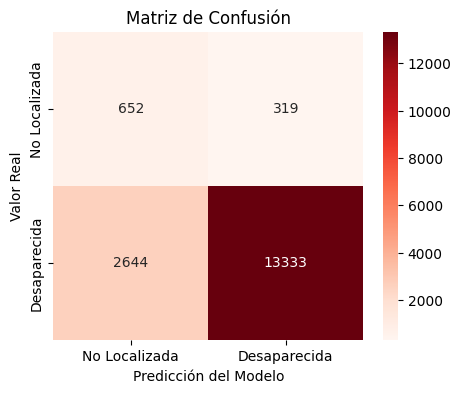

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamos al modelo (Random Forest con balanceo de pesos)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=12)
modelo_rf.fit(X_train, y_train)

# Predecimos con el set de prueba
y_pred = modelo_rf.predict(X_test)

# Reporte
print("--- MÉTRICAS DE DESEMPEÑO PRINCIPALES ---")
print(f"Accuracy (Exactitud) : {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall General       : {recall_score(y_test, y_pred):.4f} ")
print(f"F1-Score             : {f1_score(y_test, y_pred):.4f}\n")

print("--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred, target_names=['NO LOCALIZADA (0)', 'DESAPARECIDA (1)']))

# Matriz de Confusión Visual
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Localizada', 'Desaparecida'], 
            yticklabels=['No Localizada', 'Desaparecida'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

### 3.3 Análisis de Variables
**¿El modelo predice la realidad del delito o los protocolos de la burocracia?**

A continuación, extraemos la importancia que el algoritmo Random Forest le dio a cada variable. 
Si el modelo se apoya fuertemente en variables operativas como los `DIAS_RETRASO` o variables estacionales como el `MES_DESAPARICION` o `ES_FIN_SEMANA` por encima del sexo o la edad, evidenciaremos un **sesgo sistémico**: la clasificación legal de la víctima no siempre es por un crimen, sino al protocolo administrativo de la entidad o al prejuicio temporal del momento del reporte.

/tmp/ipykernel_18946/2733578834.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')


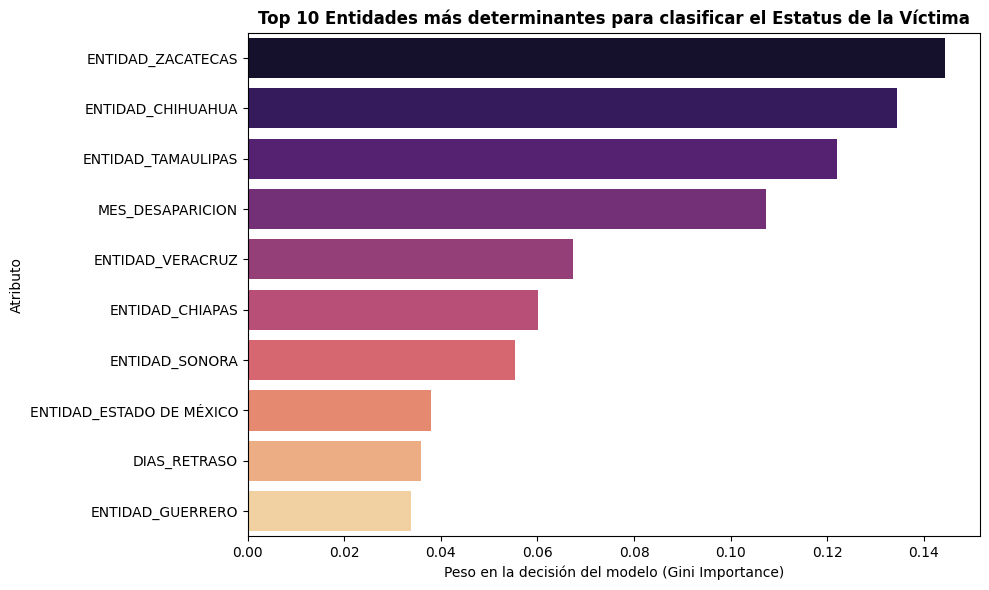

In [3]:
# Extraemos la importancia matemática de las variables según el árbol de decisión
importancias = modelo_rf.feature_importances_
nombres_columnas = X_train.columns

df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
# Tomamos las 10 entidades más importantes
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Grafica
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')
plt.title('Top 10 Entidades más determinantes para clasificar el Estatus de la Víctima', fontweight='bold', fontsize=12)
plt.xlabel('Peso en la decisión del modelo (Gini Importance)')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

### 3.4 Conclusión: 

Al evaluar el modelo de Random Forest mediante la técnica de Feature Importance, encontramos que responde a la pregunta de si el modelo captura la realidad del fenómeno o los sesgos del sistema. 

La variable **`DIAS_RETRASO`** (el tiempo transcurrido entre la desaparición y el registro oficial) domina por completo la predicción del modelo, con un peso cercano a 0.50, superando ampliamente a factores demográficos como la `EDAD` (~0.20) o el `SEXO` (< 0.05). 

**¿Qué significa esto?**
El modelo está reflejando un sesgo operativo y burocráticoen el RNPDNO. La etiqueta legal de `ESTATUS_VICTIMA` no se está asignando primordialmente por la naturaleza del hecho (si hay indicios de un delito de desaparición forzada contra la ausencia de la persona), sino por el tiempo que la familia tarda en denunciar. 

Esto nos indica que las autoridades asumen prejuzgadamente el estatus de la víctima basados en los tiempos administrativos. Por lo tanto, concluimos que nuestro modelo predice de manera eficiente, pero lo que predice **son los sesgos burocraticos**.